# 🧠 Comprehensive Prompt Engineering Analysis
## Interview Approach | Chain-of-Thought | Tree-of-Thought | Zero-Shot | Few-Shot

---
> **Powered by Groq API** | Structured pipelines | Visual metrics | Comparative analysis

### 📋 Table of Contents
1. Setup & API Configuration
2. Pipeline Architecture
3. Interview Approach
4. Chain-of-Thought (CoT) Prompting
5. Tree-of-Thought (ToT) Prompting
6. Zero-Shot Prompting
7. Few-Shot Prompting
8. Comparative Analysis & Visualizations
9. Applications & Conclusions

## 📦 Cell 1: Install Dependencies

In [1]:
# Install required packages
!pip install groq pandas numpy matplotlib seaborn plotly rich getpass4 tiktoken -q
print("✅ All packages installed successfully!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 8.9 MB/s eta 0:00:00
✅ All packages installed successfully!


## 🔑 Cell 2: API Key Configuration (Secure Input)

In [2]:
import getpass
import os

print("="*60)
print("🔐 GROQ API KEY CONFIGURATION")
print("="*60)
print("Get your FREE API key at: https://console.groq.com/keys")
print("-"*60)

GROQ_API_KEY = getpass.getpass("🔑 Enter your Groq API Key (hidden): ")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

print("\n✅ API Key set! Key preview:", GROQ_API_KEY[:8] + "..." + GROQ_API_KEY[-4:])
print("="*60)

🔐 GROQ API KEY CONFIGURATION
Get your FREE API key at: https://console.groq.com/keys
------------------------------------------------------------
🔑 Enter your Groq API Key (hidden): ··········

✅ API Key set! Key preview: gsk_acc2...yA2d


## 🏗️ Cell 3: Core Pipeline Architecture

In [5]:
import time
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from groq import Groq
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional, Tuple
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# GLOBAL CONFIG
# ─────────────────────────────────────────────
MODEL = "openai/gpt-oss-20b"          # Fast, free-tier Groq model
MODEL_LARGE = "openai/gpt-oss-120b"   # Larger model for complex tasks
MAX_TOKENS = 1024
TEMPERATURE = 0.7

# Color palette for visualization
COLORS = {
    'interview':  '#FF6B6B',
    'cot':        '#4ECDC4',
    'tot':        '#45B7D1',
    'zero_shot':  '#96CEB4',
    'few_shot':   '#FFEAA7',
    'background': '#2D3436',
    'text':       '#DFE6E9'
}

plt.rcParams.update({
    'figure.facecolor': '#1E1E2E',
    'axes.facecolor':   '#2D2D44',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'axes.titlecolor':  'white',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

# ─────────────────────────────────────────────
# DATA CLASS FOR RESULTS
# ─────────────────────────────────────────────
@dataclass
class PromptResult:
    technique:        str
    prompt:           str
    response:         str
    latency_ms:       float
    input_tokens:     int
    output_tokens:    int
    total_tokens:     int
    task:             str
    model:            str
    timestamp:        str = field(default_factory=lambda: datetime.now().isoformat())
    score:            float = 0.0
    reasoning_depth:  float = 0.0
    coherence:        float = 0.0
    completeness:     float = 0.0


# ─────────────────────────────────────────────
# GROQ CLIENT WRAPPER
# ─────────────────────────────────────────────
class GroqPipeline:
    """Centralized Groq API pipeline with metrics tracking."""

    def __init__(self, api_key: str):
        self.client = Groq(api_key=api_key)
        self.results: List[PromptResult] = []
        self.call_count = 0
        print("✅ GroqPipeline initialized!")
        print(f"   Model (default): {MODEL}")
        print(f"   Model (large):   {MODEL_LARGE}")

    def call(
        self,
        messages: List[Dict],
        technique: str,
        task: str,
        model: str = MODEL,
        temperature: float = TEMPERATURE,
        max_tokens: int = MAX_TOKENS,
        verbose: bool = True
    ) -> PromptResult:
        """Make an API call and return a structured PromptResult."""
        self.call_count += 1
        prompt_text = "\n".join([m["content"] for m in messages])

        if verbose:
            print(f"\n📡 API Call #{self.call_count} | Technique: {technique} | Task: {task[:50]}")

        start = time.time()
        try:
            response = self.client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=temperature,
                max_tokens=max_tokens
            )
            elapsed = (time.time() - start) * 1000

            content      = response.choices[0].message.content
            usage        = response.usage
            in_tok       = usage.prompt_tokens
            out_tok      = usage.completion_tokens
            total_tok    = usage.total_tokens

            result = PromptResult(
                technique=technique,
                prompt=prompt_text,
                response=content,
                latency_ms=round(elapsed, 2),
                input_tokens=in_tok,
                output_tokens=out_tok,
                total_tokens=total_tok,
                task=task,
                model=model
            )
            result = self._score_result(result)
            self.results.append(result)

            if verbose:
                print(f"   ⏱  Latency:  {elapsed:.0f}ms")
                print(f"   🔢 Tokens:   in={in_tok}, out={out_tok}, total={total_tok}")
                print(f"   📊 Score:    {result.score:.2f}/10")

            return result

        except Exception as e:
            print(f"   ❌ Error: {e}")
            raise

    def _score_result(self, result: PromptResult) -> PromptResult:
        """Heuristic-based scoring of response quality."""
        resp = result.response
        words = resp.split()
        sentences = resp.split('.')

        # Reasoning depth: presence of logical connectors / steps
        reasoning_markers = ['because', 'therefore', 'thus', 'hence', 'step', 'first',
                              'second', 'finally', 'reasoning', 'analysis', 'consider',
                              'however', 'moreover', 'furthermore', 'conclusion']
        reasoning_count = sum(1 for w in words if w.lower() in reasoning_markers)
        result.reasoning_depth = min(10.0, reasoning_count * 0.8)

        # Coherence: average sentence length (too short or too long = bad)
        avg_sent_len = len(words) / max(len(sentences), 1)
        result.coherence = min(10.0, max(0, 10 - abs(avg_sent_len - 18) * 0.3))

        # Completeness: output token ratio relative to max_tokens
        result.completeness = min(10.0, (result.output_tokens / MAX_TOKENS) * 10)

        # Composite score
        result.score = round(
            (result.reasoning_depth * 0.4) +
            (result.coherence * 0.35) +
            (result.completeness * 0.25), 2
        )
        return result

    def to_dataframe(self) -> pd.DataFrame:
        """Convert all results to a DataFrame for analysis."""
        return pd.DataFrame([{
            'technique':       r.technique,
            'task':            r.task,
            'model':           r.model,
            'latency_ms':      r.latency_ms,
            'input_tokens':    r.input_tokens,
            'output_tokens':   r.output_tokens,
            'total_tokens':    r.total_tokens,
            'score':           r.score,
            'reasoning_depth': r.reasoning_depth,
            'coherence':       r.coherence,
            'completeness':    r.completeness,
            'response_len':    len(r.response),
            'timestamp':       r.timestamp
        } for r in self.results])


# Initialize pipeline
pipeline = GroqPipeline(api_key=GROQ_API_KEY)
print("\n🚀 Pipeline ready for experiments!")

✅ GroqPipeline initialized!
   Model (default): openai/gpt-oss-20b
   Model (large):   openai/gpt-oss-120b

🚀 Pipeline ready for experiments!


## 🎤 Cell 4: Interview Approach

> **Interview Approach**: The LLM acts as an interviewer — asking clarifying questions before generating a final answer. This is a multi-turn technique that gathers context progressively.

In [6]:
print("="*70)
print("🎤  TECHNIQUE 1: INTERVIEW APPROACH")
print("="*70)

# ─────────────────────────────────────────────
# INTERVIEW PIPELINE
# ─────────────────────────────────────────────

class InterviewPipeline:
    """Multi-turn interview-based prompting pipeline."""

    def __init__(self, groq_pipeline: GroqPipeline):
        self.gp = groq_pipeline
        self.conversation_history = []

    def run(self, initial_task: str, user_answers: List[str], task_name: str) -> PromptResult:
        print(f"\n📋 Task: {task_name}")
        print("-" * 60)

        # Step 1: LLM generates clarifying questions
        interviewer_prompt = f"""\
You are an expert AI assistant using the Interview Approach.
Your job is to first ask 3 targeted clarifying questions before answering.

The user's request is:
\"\"\"
{initial_task}
\"\"\"

Generate exactly 3 clarifying questions, numbered 1-3, to understand the user's need better.
Be concise. Do NOT answer the task yet."""

        messages = [{"role": "user", "content": interviewer_prompt}]

        q_result = self.gp.call(
            messages=messages,
            technique="Interview (Questions)",
            task=task_name,
            max_tokens=300,
            verbose=False
        )

        print("\n🤖 LLM Interviewer Questions:")
        print(q_result.response)

        # Step 2: Simulate user answers
        answers_text = "\n".join([f"{i+1}. {ans}" for i, ans in enumerate(user_answers)])
        print(f"\n👤 User Answers (simulated):\n{answers_text}")

        # Step 3: Final answer with context
        final_prompt = f"""\
You are an expert AI assistant.
The user requested: \"{initial_task}\"

You asked clarifying questions and received these answers:
{answers_text}

Now provide a comprehensive, tailored final answer using all this context.
Structure your response with clear sections."""

        final_messages = [
            {"role": "user", "content": final_prompt}
        ]

        final_result = self.gp.call(
            messages=final_messages,
            technique="Interview",
            task=task_name,
            max_tokens=MAX_TOKENS,
            verbose=True
        )

        print("\n✅ Final Response (Interview Approach):")
        print("-" * 60)
        print(final_result.response[:800] + "..." if len(final_result.response) > 800 else final_result.response)
        return final_result


# ─── EXAMPLE 1: Business Strategy ───
interview_pipe = InterviewPipeline(pipeline)

r_interview_1 = interview_pipe.run(
    initial_task="Help me build a marketing strategy for my product.",
    user_answers=[
        "It's a mobile app for remote fitness coaching, targeting professionals aged 25-40",
        "Budget is $5000/month, focused on digital channels",
        "Main competitors are Peloton and Nike Training Club"
    ],
    task_name="Marketing Strategy"
)

print("\n" + "="*70)

🎤  TECHNIQUE 1: INTERVIEW APPROACH

📋 Task: Marketing Strategy
------------------------------------------------------------

🤖 LLM Interviewer Questions:
1. What type of product are you selling (e.g., physical goods, digital service, SaaS, etc.)?  
2. Who is your target audience and what are their key demographics or psychographics?  
3. What are your primary marketing goals (e.g., brand awareness, lead generation, sales conversion, customer retention)?

👤 User Answers (simulated):
1. It's a mobile app for remote fitness coaching, targeting professionals aged 25-40
2. Budget is $5000/month, focused on digital channels
3. Main competitors are Peloton and Nike Training Club

📡 API Call #2 | Technique: Interview | Task: Marketing Strategy
   ⏱  Latency:  1175ms
   🔢 Tokens:   in=168, out=1024, total=1192
   📊 Score:    4.31/10

✅ Final Response (Interview Approach):
------------------------------------------------------------
## 📈 Remote‑Fit Coaching App – Digital‑First Marketing Strategy

In [7]:
# ─── EXAMPLE 2: Technical Problem ───
r_interview_2 = interview_pipe.run(
    initial_task="Explain how to optimize my database.",
    user_answers=[
        "PostgreSQL with about 10 million rows in the main table",
        "The main issue is slow SELECT queries with multiple JOINs taking 3-5 seconds",
        "We have a SaaS application with 500 concurrent users at peak"
    ],
    task_name="Database Optimization"
)

print("\n" + "="*70)
print("✅ Interview Approach — Both examples complete!")


📋 Task: Database Optimization
------------------------------------------------------------

🤖 LLM Interviewer Questions:
1. What type of database are you using (e.g., relational, NoSQL, graph)?  
2. What specific performance issues are you experiencing (e.g., slow queries, high latency, storage growth)?  
3. Are there particular workloads or use‑cases (e.g., read‑heavy, write‑heavy, analytics) that dominate your system?

👤 User Answers (simulated):
1. PostgreSQL with about 10 million rows in the main table
2. The main issue is slow SELECT queries with multiple JOINs taking 3-5 seconds
3. We have a SaaS application with 500 concurrent users at peak

📡 API Call #4 | Technique: Interview | Task: Database Optimization
   ⏱  Latency:  1167ms
   🔢 Tokens:   in=171, out=1024, total=1195
   📊 Score:    5.77/10

✅ Final Response (Interview Approach):
------------------------------------------------------------
## 1. Quick‑Start Checklist  
| ✅ | Item | Why it matters | How to act |
|---|------

## 🔗 Cell 5: Chain-of-Thought (CoT) Prompting

> **CoT Prompting**: Instructs the model to show its reasoning step-by-step before arriving at the answer. Dramatically improves performance on reasoning tasks.

In [8]:
print("="*70)
print("🔗  TECHNIQUE 2: CHAIN-OF-THOUGHT (CoT) PROMPTING")
print("="*70)


class CoTPipeline:
    """Chain-of-Thought prompting pipeline with structured step extraction."""

    def __init__(self, groq_pipeline: GroqPipeline):
        self.gp = groq_pipeline

    def build_cot_prompt(self, task: str, examples: Optional[List[Dict]] = None) -> str:
        """Build a CoT prompt with optional few-shot examples."""
        few_shot_block = ""
        if examples:
            for ex in examples:
                few_shot_block += f"\nQ: {ex['question']}\nThinking:\n{ex['reasoning']}\nAnswer: {ex['answer']}\n---"

        prompt = f"""\
You are an expert problem-solver. Use Chain-of-Thought reasoning.
Show your thinking process step-by-step BEFORE giving your final answer.
Format your response exactly as:

**Thinking:**
Step 1: [reasoning]
Step 2: [reasoning]
Step 3: [reasoning]
... (as many steps as needed)

**Final Answer:**
[your conclusion]
{few_shot_block}
---
Now solve this:
Q: {task}"""
        return prompt

    def run(self, task: str, task_name: str, examples: Optional[List[Dict]] = None) -> PromptResult:
        print(f"\n📋 Task: {task_name}")
        print(f"   Prompt: {task[:80]}..." if len(task) > 80 else f"   Prompt: {task}")
        print("-" * 60)

        prompt = self.build_cot_prompt(task, examples)
        messages = [{"role": "user", "content": prompt}]

        result = self.gp.call(
            messages=messages,
            technique="CoT",
            task=task_name,
            temperature=0.3,  # Lower temp for logical reasoning
            max_tokens=MAX_TOKENS,
            verbose=True
        )

        print("\n🔗 CoT Response:")
        print("-" * 60)
        print(result.response[:1000] + "..." if len(result.response) > 1000 else result.response)
        return result

    def extract_steps(self, response: str) -> List[str]:
        """Extract reasoning steps from CoT response."""
        steps = re.findall(r'Step \d+:.*?(?=Step \d+:|\*\*Final|$)', response, re.DOTALL)
        return [s.strip() for s in steps if s.strip()]


cot_pipe = CoTPipeline(pipeline)

# ─── TASK 1: Math / Logic ───
r_cot_1 = cot_pipe.run(
    task="A train travels 120 miles in 2 hours, then 180 miles in 3 hours. "
         "What is the average speed for the entire journey? Explain your reasoning.",
    task_name="Math - Average Speed"
)

print("\n" + "="*70)

🔗  TECHNIQUE 2: CHAIN-OF-THOUGHT (CoT) PROMPTING

📋 Task: Math - Average Speed
   Prompt: A train travels 120 miles in 2 hours, then 180 miles in 3 hours. What is the ave...
------------------------------------------------------------

📡 API Call #5 | Technique: CoT | Task: Math - Average Speed
   ⏱  Latency:  388ms
   🔢 Tokens:   in=191, out=264, total=455
   📊 Score:    5.89/10

🔗 CoT Response:
------------------------------------------------------------
**Thinking:**
Step 1: Identify the total distance traveled.  
- First segment: 120 miles  
- Second segment: 180 miles  
- Total distance = 120 + 180 = 300 miles.

Step 2: Identify the total time taken.  
- First segment: 2 hours  
- Second segment: 3 hours  
- Total time = 2 + 3 = 5 hours.

Step 3: Compute the average speed using the formula  
\[
\text{Average speed} = \frac{\text{Total distance}}{\text{Total time}}.
\]
Plugging in the numbers:  
\[
\text{Average speed} = \frac{300 \text{ miles}}{5 \text{ hours}} = 60 \text{ miles p

In [9]:
# ─── TASK 2: Ethical Reasoning ───
r_cot_2 = cot_pipe.run(
    task="Should a company lay off 20% of employees to remain profitable and save the other 80% of jobs, "
         "or try other cost-cutting measures first even if it risks the entire company? "
         "Reason through the ethical and business considerations.",
    task_name="Ethical Reasoning - Layoffs"
)

print("\n" + "="*70)


📋 Task: Ethical Reasoning - Layoffs
   Prompt: Should a company lay off 20% of employees to remain profitable and save the othe...
------------------------------------------------------------

📡 API Call #6 | Technique: CoT | Task: Ethical Reasoning - Layoffs
   ⏱  Latency:  1016ms
   🔢 Tokens:   in=204, out=878, total=1082
   📊 Score:    9.17/10

🔗 CoT Response:
------------------------------------------------------------
**Thinking:**
Step 1: Identify the core dilemma – the company faces a financial crisis that threatens its survival. It can either cut 20% of staff to stay profitable or attempt other cost‑cutting measures that might risk the entire company if they fail.

Step 2: List the stakeholders affected. Employees (both those potentially laid off and those who remain), customers, shareholders, suppliers, the local community, and the company’s own culture and brand reputation.

Step 3: Evaluate the business impact of a 20% layoff.  
- **Pros:** Immediate cash flow improvement, 

In [10]:
# ─── TASK 3: Code Debugging with CoT ───
r_cot_3 = cot_pipe.run(
    task="""Debug this Python code and explain what's wrong:
def calculate_average(numbers):
    total = 0
    for num in numbers:
        total += num
    return total / len(numbers)

result = calculate_average([])
print(result)
""",
    task_name="Code Debugging"
)

print("\n" + "="*70)
print("✅ Chain-of-Thought — All 3 tasks complete!")


📋 Task: Code Debugging
   Prompt: Debug this Python code and explain what's wrong:
def calculate_average(numbers):...
------------------------------------------------------------

📡 API Call #7 | Technique: CoT | Task: Code Debugging
   ⏱  Latency:  617ms
   🔢 Tokens:   in=203, out=484, total=687
   📊 Score:    6.25/10

🔗 CoT Response:
------------------------------------------------------------
**Thinking:**
Step 1: Read the code and understand its intent.  
- `calculate_average` sums all elements in `numbers` and divides by the count.  
- `result = calculate_average([])` passes an empty list.  
- `print(result)` will try to print the returned value.

Step 2: Identify the runtime error.  
- Inside `calculate_average`, `len(numbers)` is `0` for an empty list.  
- Division by zero (`total / 0`) raises a `ZeroDivisionError`.

Step 3: Consider what the function should do with an empty input.  
- Common approaches:  
  1. Return `None` or `float('nan')`.  
  2. Raise a custom exception wi

## 🌳 Cell 6: Tree-of-Thought (ToT) Prompting

> **ToT Prompting**: Explores multiple reasoning branches simultaneously, evaluates each path, and selects the best solution. Ideal for complex problems requiring exploration of alternatives.

In [11]:
print("="*70)
print("🌳  TECHNIQUE 3: TREE-OF-THOUGHT (ToT) PROMPTING")
print("="*70)


class ToTPipeline:
    """Tree-of-Thought prompting pipeline with branch exploration."""

    def __init__(self, groq_pipeline: GroqPipeline, n_branches: int = 3):
        self.gp = groq_pipeline
        self.n_branches = n_branches

    def build_tot_prompt(self, task: str) -> str:
        return f"""\
You are an expert using Tree-of-Thought reasoning.
Explore {self.n_branches} different reasoning branches/approaches for the problem below.
Then evaluate each branch critically and select the best solution.

Format your response EXACTLY as:

═══ BRANCH 1: [Branch Name] ═══
Approach: [describe this reasoning path]
Reasoning: [detailed thoughts on this branch]
Pros: [advantages]
Cons: [disadvantages]
Score: [X/10]

═══ BRANCH 2: [Branch Name] ═══
Approach: [describe this reasoning path]
Reasoning: [detailed thoughts on this branch]
Pros: [advantages]
Cons: [disadvantages]
Score: [X/10]

═══ BRANCH 3: [Branch Name] ═══
Approach: [describe this reasoning path]
Reasoning: [detailed thoughts on this branch]
Pros: [advantages]
Cons: [disadvantages]
Score: [X/10]

══════════════════════════════════
🏆 BEST SOLUTION (Selected Branch: [name]):
[Comprehensive final answer based on the best branch]
══════════════════════════════════

Problem to solve:
{task}"""

    def run(self, task: str, task_name: str) -> PromptResult:
        print(f"\n📋 Task: {task_name}")
        print(f"   Branches to explore: {self.n_branches}")
        print("-" * 60)

        prompt = self.build_tot_prompt(task)
        messages = [{"role": "user", "content": prompt}]

        result = self.gp.call(
            messages=messages,
            technique="ToT",
            task=task_name,
            model=MODEL_LARGE,  # Use larger model for ToT complexity
            temperature=0.8,
            max_tokens=MAX_TOKENS,
            verbose=True
        )

        print("\n🌳 ToT Response:")
        print("-" * 60)
        print(result.response[:1200] + "..." if len(result.response) > 1200 else result.response)
        return result

    def extract_branches(self, response: str) -> List[Dict]:
        """Extract branch scores from ToT response."""
        branches = []
        pattern = r'BRANCH (\d+): ([^═]+).*?Score: (\d+)/10'
        matches = re.findall(pattern, response, re.DOTALL)
        for m in matches:
            branches.append({'branch': m[0], 'name': m[1].strip(), 'score': int(m[2])})
        return branches


tot_pipe = ToTPipeline(pipeline, n_branches=3)

# ─── TASK 1: Business Decision ───
r_tot_1 = tot_pipe.run(
    task="A startup with $500K runway needs to decide: (A) Hire 5 more engineers to build faster, "
         "(B) Invest in marketing to acquire customers first, or (C) Pivot to a different market. "
         "They have 1 paying customer and 6 months of runway.",
    task_name="Startup Strategy Decision"
)

print("\n" + "="*70)

🌳  TECHNIQUE 3: TREE-OF-THOUGHT (ToT) PROMPTING

📋 Task: Startup Strategy Decision
   Branches to explore: 3
------------------------------------------------------------

📡 API Call #8 | Technique: ToT | Task: Startup Strategy Decision
   ⏱  Latency:  2604ms
   🔢 Tokens:   in=370, out=1024, total=1394
   📊 Score:    5.88/10

🌳 ToT Response:
------------------------------------------------------------
═══ BRANCH 1: Engineering‑First Acceleration ═══  
**Approach:** Use the $500 K to hire 5 additional engineers (or contract talent) so the product can be built, refined, and expanded rapidly. Aim to create a robust, feature‑complete MVP that can attract more paying customers and potentially raise a follow‑on round.  

**Reasoning:**  
- The core value proposition of most early‑stage tech startups is the product. A stronger engineering team can shorten development cycles, fix bugs, and add high‑impact features that current customers (and prospects) demand.  
- With only one paying customer,

In [12]:
# ─── TASK 2: Complex Problem Solving ───
r_tot_2 = tot_pipe.run(
    task="Design the best algorithm to find the shortest path in a weighted graph "
         "with 1 million nodes where edge weights can be negative. "
         "Consider time complexity, space complexity, and practical implementation.",
    task_name="Algorithm Design - Shortest Path"
)

print("\n" + "="*70)
print("✅ Tree-of-Thought — All tasks complete!")


📋 Task: Algorithm Design - Shortest Path
   Branches to explore: 3
------------------------------------------------------------

📡 API Call #9 | Technique: ToT | Task: Algorithm Design - Shortest Path
   ⏱  Latency:  2288ms
   🔢 Tokens:   in=349, out=1024, total=1373
   📊 Score:    5.62/10

🌳 ToT Response:
------------------------------------------------------------
═══ BRANCH 1: Classic Bellman‑Ford ═══  
**Approach:**  
Run the standard Bellman‑Ford relaxation loop from the source vertex. Perform |V|‑1 passes over all edges, updating distances, then a final pass to detect any negative‑weight cycles.  

**Reasoning:**  
Bellman‑Ford works on any directed weighted graph, even with negative edges, and guarantees correct shortest‑path distances (or detection of a negative cycle). It requires only O(|V|) extra space for the distance array and predecessor pointers.  

**Pros:**  
- Simple to implement; no auxiliary data structures.  
- Handles negative edges and detects negative cycles au

## 🎯 Cell 7: Zero-Shot Prompting

> **Zero-Shot**: No examples provided. The model relies entirely on its pre-trained knowledge. Fast and simple but may lack precision.

In [13]:
print("="*70)
print("🎯  TECHNIQUE 4: ZERO-SHOT PROMPTING")
print("="*70)


class ZeroShotPipeline:
    """Zero-shot prompting pipeline — no examples provided."""

    def __init__(self, groq_pipeline: GroqPipeline):
        self.gp = groq_pipeline

    def run(self, task: str, task_name: str, system_prompt: str = "") -> PromptResult:
        print(f"\n📋 Task: {task_name}")
        print("-" * 60)

        messages = []
        if system_prompt:
            messages.append({"role": "system", "content": system_prompt})
        messages.append({"role": "user", "content": task})

        result = self.gp.call(
            messages=messages,
            technique="Zero-Shot",
            task=task_name,
            temperature=0.7,
            max_tokens=MAX_TOKENS,
            verbose=True
        )

        print("\n🎯 Zero-Shot Response:")
        print("-" * 60)
        print(result.response[:600] + "..." if len(result.response) > 600 else result.response)
        return result


zero_shot = ZeroShotPipeline(pipeline)

# Benchmark tasks (same tasks used for Few-Shot comparison)
BENCHMARK_TASKS = [
    {
        "name": "Sentiment Classification",
        "prompt": "Classify the sentiment of this review as Positive, Negative, or Neutral: "
                  "'The product arrived late and the packaging was damaged, but the quality exceeded my expectations.'",
    },
    {
        "name": "Text Summarization",
        "prompt": "Summarize this in 2 sentences: "
                  "Artificial intelligence has rapidly evolved from rule-based systems to sophisticated neural networks "
                  "capable of performing complex cognitive tasks. Modern AI models like large language models can understand "
                  "context, generate creative content, solve mathematical problems, and assist in scientific discovery. "
                  "These systems are trained on vast datasets and use transformer architectures with attention mechanisms.",
    },
    {
        "name": "Entity Extraction",
        "prompt": "Extract all named entities (people, organizations, locations, dates) from: "
                  "'On March 15, 2023, Elon Musk announced that Tesla would open a new Gigafactory in Mexico City, "
                  "partnering with the Mexican government and Stanford University researchers.'",
    },
    {
        "name": "Code Generation",
        "prompt": "Write a Python function that checks if a string is a palindrome, ignoring spaces and capitalization.",
    },
    {
        "name": "Math Word Problem",
        "prompt": "If 8 workers can build a wall in 10 days, how many days will 5 workers take to build the same wall?",
    }
]

zero_shot_results = []
for task in BENCHMARK_TASKS:
    r = zero_shot.run(
        task=task["prompt"],
        task_name=task["name"],
        system_prompt="You are a helpful AI assistant. Answer directly and concisely."
    )
    zero_shot_results.append(r)
    time.sleep(0.5)  # Rate limit courtesy

print("\n" + "="*70)
print(f"✅ Zero-Shot complete! {len(zero_shot_results)} tasks done.")

🎯  TECHNIQUE 4: ZERO-SHOT PROMPTING

📋 Task: Sentiment Classification
------------------------------------------------------------

📡 API Call #10 | Technique: Zero-Shot | Task: Sentiment Classification
   ⏱  Latency:  266ms
   🔢 Tokens:   in=121, out=132, total=253
   📊 Score:    2.04/10

🎯 Zero-Shot Response:
------------------------------------------------------------
Positive

📋 Task: Text Summarization
------------------------------------------------------------

📡 API Call #11 | Technique: Zero-Shot | Task: Text Summarization
   ⏱  Latency:  255ms
   🔢 Tokens:   in=157, out=135, total=292
   📊 Score:    3.58/10

🎯 Zero-Shot Response:
------------------------------------------------------------
Artificial intelligence has progressed from rule-based systems to sophisticated neural networks, enabling machines to perform complex cognitive tasks. Modern large language models, trained on vast datasets and built on transformer architectures with attention mechanisms, can understand cont

## 📚 Cell 8: Few-Shot Prompting

> **Few-Shot**: Provides 2–5 examples (demonstrations) before the actual task. Guides the model's format and reasoning style significantly.

In [14]:
print("="*70)
print("📚  TECHNIQUE 5: FEW-SHOT PROMPTING")
print("="*70)


class FewShotPipeline:
    """Few-shot prompting pipeline with structured example injection."""

    def __init__(self, groq_pipeline: GroqPipeline):
        self.gp = groq_pipeline

    def build_few_shot_prompt(
        self,
        task: str,
        examples: List[Dict[str, str]],
        instruction: str = ""
    ) -> str:
        """Build a few-shot prompt with structured examples."""
        prompt_parts = []
        if instruction:
            prompt_parts.append(f"Instruction: {instruction}\n")

        prompt_parts.append("Here are some examples:\n")
        for i, ex in enumerate(examples, 1):
            prompt_parts.append(f"Example {i}:")
            prompt_parts.append(f"Input: {ex['input']}")
            prompt_parts.append(f"Output: {ex['output']}\n")

        prompt_parts.append("Now complete this:")
        prompt_parts.append(f"Input: {task}")
        prompt_parts.append("Output:")

        return "\n".join(prompt_parts)

    def run(
        self,
        task: str,
        task_name: str,
        examples: List[Dict[str, str]],
        instruction: str = ""
    ) -> PromptResult:
        print(f"\n📋 Task: {task_name} ({len(examples)} examples provided)")
        print("-" * 60)

        prompt = self.build_few_shot_prompt(task, examples, instruction)
        messages = [{"role": "user", "content": prompt}]

        result = self.gp.call(
            messages=messages,
            technique="Few-Shot",
            task=task_name,
            temperature=0.5,
            max_tokens=MAX_TOKENS,
            verbose=True
        )

        print("\n📚 Few-Shot Response:")
        print("-" * 60)
        print(result.response[:600] + "..." if len(result.response) > 600 else result.response)
        return result


few_shot = FewShotPipeline(pipeline)

# ─── SENTIMENT with examples ───
sentiment_examples = [
    {"input": "This restaurant has amazing food and great service!",
     "output": "Sentiment: Positive\nReason: Uses positive adjectives 'amazing' and 'great'"},
    {"input": "The delivery was extremely late and the food was cold.",
     "output": "Sentiment: Negative\nReason: Complaints about delivery and food quality"},
    {"input": "The product does exactly what it says it does.",
     "output": "Sentiment: Neutral\nReason: Factual statement without strong positive or negative emotion"}
]

few_shot_results = []

r_fs_1 = few_shot.run(
    task="The product arrived late and the packaging was damaged, but the quality exceeded my expectations.",
    task_name="Sentiment Classification",
    examples=sentiment_examples,
    instruction="Classify sentiment as Positive, Negative, or Neutral with a brief reason."
)
few_shot_results.append(r_fs_1)
time.sleep(0.5)

📚  TECHNIQUE 5: FEW-SHOT PROMPTING

📋 Task: Sentiment Classification (3 examples provided)
------------------------------------------------------------

📡 API Call #15 | Technique: Few-Shot | Task: Sentiment Classification
   ⏱  Latency:  447ms
   🔢 Tokens:   in=222, out=317, total=539
   📊 Score:    3.75/10

📚 Few-Shot Response:
------------------------------------------------------------
Sentiment: Neutral  
Reason: The statement contains both negative points (late arrival, damaged packaging) and a positive point (quality exceeded expectations), resulting in a mixed overall tone.


In [15]:
# ─── SUMMARIZATION with examples ───
summary_examples = [
    {"input": "The Industrial Revolution began in Britain in the late 18th century and transformed manufacturing from hand production to machine-based processes. It led to urbanization, economic growth, and social changes.",
     "output": "The Industrial Revolution transformed Britain's manufacturing through mechanization, driving urbanization and economic growth."},
    {"input": "Climate change refers to long-term shifts in global temperatures and weather patterns. While natural causes exist, human activities like burning fossil fuels have been the main driver since the 1800s, causing rising temperatures, extreme weather, and sea level rise.",
     "output": "Climate change involves long-term temperature shifts driven primarily by human fossil fuel use, resulting in extreme weather and rising seas."}
]

r_fs_2 = few_shot.run(
    task="Artificial intelligence has rapidly evolved from rule-based systems to sophisticated neural networks "
         "capable of performing complex cognitive tasks. Modern AI models like large language models can understand "
         "context, generate creative content, solve mathematical problems, and assist in scientific discovery. "
         "These systems are trained on vast datasets and use transformer architectures with attention mechanisms.",
    task_name="Text Summarization",
    examples=summary_examples,
    instruction="Summarize in one concise sentence preserving the core meaning."
)
few_shot_results.append(r_fs_2)
time.sleep(0.5)


📋 Task: Text Summarization (2 examples provided)
------------------------------------------------------------

📡 API Call #16 | Technique: Few-Shot | Task: Text Summarization
   ⏱  Latency:  296ms
   🔢 Tokens:   in=300, out=165, total=465
   📊 Score:    3.22/10

📚 Few-Shot Response:
------------------------------------------------------------
AI has evolved from rule‑based systems to transformer‑based neural networks that understand context, generate creative content, solve math problems, and aid scientific discovery.


In [16]:
# ─── ENTITY EXTRACTION with examples ───
entity_examples = [
    {"input": "In 2020, Jeff Bezos stepped down from Amazon in Seattle to focus on Blue Origin.",
     "output": "People: Jeff Bezos\nOrganizations: Amazon, Blue Origin\nLocations: Seattle\nDates: 2020"},
    {"input": "Apple CEO Tim Cook met with EU regulators in Brussels on January 10, 2024.",
     "output": "People: Tim Cook\nOrganizations: Apple, EU\nLocations: Brussels\nDates: January 10, 2024"}
]

r_fs_3 = few_shot.run(
    task="On March 15, 2023, Elon Musk announced that Tesla would open a new Gigafactory in Mexico City, "
         "partnering with the Mexican government and Stanford University researchers.",
    task_name="Entity Extraction",
    examples=entity_examples,
    instruction="Extract all named entities grouped by type: People, Organizations, Locations, Dates."
)
few_shot_results.append(r_fs_3)
time.sleep(0.5)


📋 Task: Entity Extraction (2 examples provided)
------------------------------------------------------------

📡 API Call #17 | Technique: Few-Shot | Task: Entity Extraction
   ⏱  Latency:  409ms
   🔢 Tokens:   in=238, out=280, total=518
   📊 Score:    3.97/10

📚 Few-Shot Response:
------------------------------------------------------------
People: Elon Musk  
Organizations: Tesla, Mexican government, Stanford University  
Locations: Mexico City  
Dates: March 15, 2023


In [17]:
# ─── CODE GENERATION with examples ───
code_examples = [
    {"input": "Write a Python function to check if a number is prime.",
     "output": """def is_prime(n):
    if n < 2: return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0: return False
    return True"""},
    {"input": "Write a Python function to reverse a string.",
     "output": """def reverse_string(s):
    return s[::-1]"""}
]

r_fs_4 = few_shot.run(
    task="Write a Python function that checks if a string is a palindrome, ignoring spaces and capitalization.",
    task_name="Code Generation",
    examples=code_examples,
    instruction="Write clean, efficient Python code with a brief docstring."
)
few_shot_results.append(r_fs_4)
time.sleep(0.5)


📋 Task: Code Generation (2 examples provided)
------------------------------------------------------------

📡 API Call #18 | Technique: Few-Shot | Task: Code Generation
   ⏱  Latency:  481ms
   🔢 Tokens:   in=214, out=352, total=566
   📊 Score:    3.37/10

📚 Few-Shot Response:
------------------------------------------------------------
```python
def is_palindrome(s: str) -> bool:
    """
    Return True if `s` is a palindrome, ignoring spaces and case.

    Parameters
    ----------
    s : str
        The input string to test.

    Returns
    -------
    bool
        True if the cleaned string reads the same forwards and backwards,
        False otherwise.
    """
    cleaned = ''.join(ch.lower() for ch in s if not ch.isspace())
    return cleaned == cleaned[::-1]
```


In [18]:
# ─── MATH with examples ───
math_examples = [
    {"input": "If 4 workers complete a job in 6 days, how long will 3 workers take?",
     "output": "Total work = 4 × 6 = 24 worker-days. Time for 3 workers = 24 ÷ 3 = 8 days."},
    {"input": "If 6 machines make 120 parts in 4 hours, how long for 4 machines to make 120 parts?",
     "output": "Rate per machine = 120 ÷ (6 × 4) = 5 parts/hour. 4 machines rate = 20 parts/hour. Time = 120 ÷ 20 = 6 hours."}
]

r_fs_5 = few_shot.run(
    task="If 8 workers can build a wall in 10 days, how many days will 5 workers take to build the same wall?",
    task_name="Math Word Problem",
    examples=math_examples,
    instruction="Show step-by-step calculation with the final numeric answer."
)
few_shot_results.append(r_fs_5)

print("\n" + "="*70)
print(f"✅ Few-Shot complete! {len(few_shot_results)} tasks done.")


📋 Task: Math Word Problem (2 examples provided)
------------------------------------------------------------

📡 API Call #19 | Technique: Few-Shot | Task: Math Word Problem
   ⏱  Latency:  260ms
   🔢 Tokens:   in=259, out=135, total=394
   📊 Score:    2.95/10

📚 Few-Shot Response:
------------------------------------------------------------
Total work = 8 workers × 10 days = **80 worker‑days**.  
Time for 5 workers = Total work ÷ Number of workers = 80 ÷ 5 = **16 days**.

✅ Few-Shot complete! 5 tasks done.


## 📊 Cell 9: Comprehensive Visualization & Metrics

In [19]:
print("="*70)
print("📊  VISUALIZATION & METRICS DASHBOARD")
print("="*70)

# Build master DataFrame
df = pipeline.to_dataframe()
print(f"\nTotal API calls tracked: {len(df)}")
print("\nData Preview:")
display(df[['technique','task','latency_ms','total_tokens','score','reasoning_depth','coherence','completeness']].head(20))

📊  VISUALIZATION & METRICS DASHBOARD

Total API calls tracked: 19

Data Preview:


,technique,task,latency_ms,total_tokens,score,reasoning_depth,coherence,completeness
0,Interview (Questions),Marketing Strategy,266.95,245,2.38,0.0,6.100000,0.966797
1,Interview,Marketing Strategy,1175.18,1192,4.31,0.0,5.181250,10.000000
2,Interview (Questions),Database Optimization,235.55,248,2.31,0.0,5.860000,1.025391
3,Interview,Database Optimization,1167.01,1195,5.77,0.0,9.340000,10.000000
4,CoT,Math - Average Speed,388.00,455,5.89,5.6,8.575000,2.578125
5,CoT,Ethical Reasoning - Layoffs,1016.04,1082,9.17,9.6,9.109091,8.574219
6,CoT,Code Debugging,616.62,687,6.25,5.6,8.069565,4.726562
7,ToT,Startup Strategy Decision,2604.38,1394,5.88,0.0,9.658333,10.000000
8,ToT,Algorithm Design - Shortest Path,2288.46,1373,5.62,0.8,8.005882,10.000000
9,Zero-Shot,Sentiment Classification,266.32,253,2.04,0.0,4.900000,1.289062


In [20]:
# ══════════════════════════════════════════════════════
# FIGURE 1: Technique Performance Overview (Radar Chart)
# ══════════════════════════════════════════════════════

# Aggregate metrics by technique
technique_map = {
    'Interview': 'Interview',
    'Interview (Questions)': 'Interview',
    'CoT': 'CoT',
    'ToT': 'ToT',
    'Zero-Shot': 'Zero-Shot',
    'Few-Shot': 'Few-Shot'
}
df['technique_group'] = df['technique'].map(technique_map)

agg = df.groupby('technique_group').agg({
    'score': 'mean',
    'reasoning_depth': 'mean',
    'coherence': 'mean',
    'completeness': 'mean',
    'latency_ms': 'mean',
    'total_tokens': 'mean'
}).round(2)

# Normalize latency (invert so lower = better visually)
agg['speed_score'] = 10 - (agg['latency_ms'] / agg['latency_ms'].max() * 10)
agg['token_efficiency'] = 10 - (agg['total_tokens'] / agg['total_tokens'].max() * 10)

print("\n📋 Aggregated Metrics by Technique:")
display(agg)


📋 Aggregated Metrics by Technique:


,score,reasoning_depth,coherence,completeness,latency_ms,total_tokens,speed_score,token_efficiency
technique_group,,,,,,,,
CoT,7.10,6.93,8.58,5.29,673.55,741.33,7.246793,4.641634
Few-Shot,3.45,0.00,8.12,2.44,378.63,496.40,8.452310,6.411999
Interview,3.69,0.00,6.62,5.50,711.17,720.00,7.093018,4.795808
ToT,5.75,0.40,8.83,10.00,2446.42,1383.50,0.000000,0.000000
Zero-Shot,2.77,0.00,6.93,1.39,265.19,270.20,8.916008,8.046982


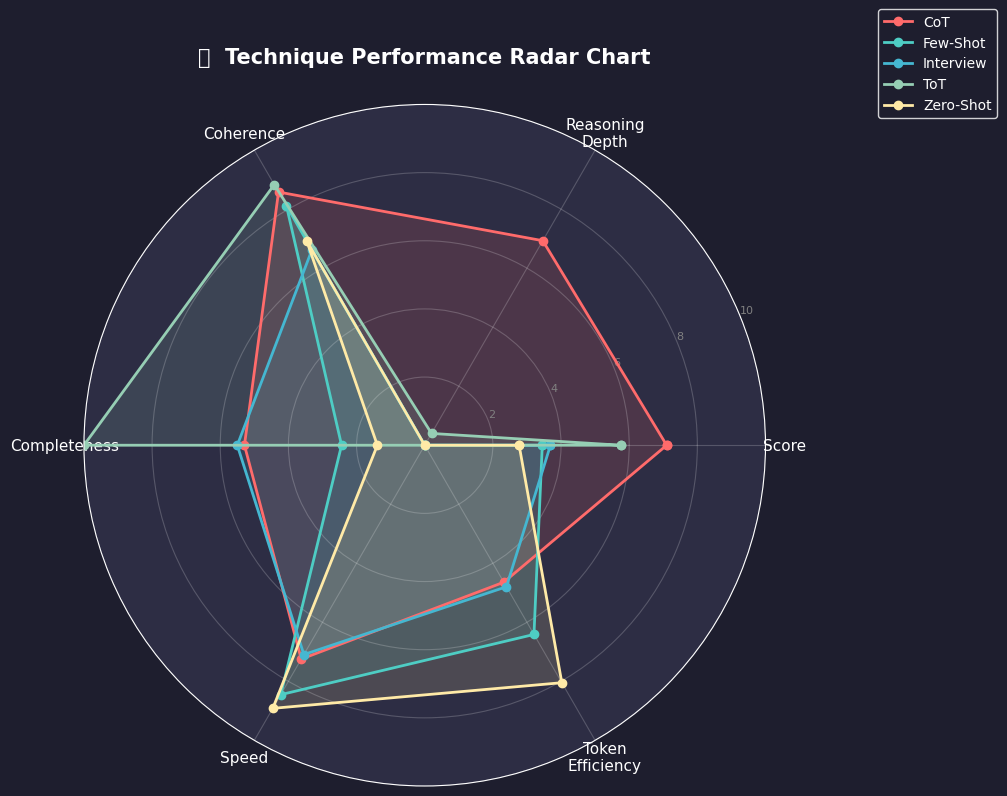

✅ Plot 1 saved


In [26]:
# ─────────────────────────────────────────────
# PLOT 1: Radar / Spider Chart
# ─────────────────────────────────────────────

categories = ['Score', 'Reasoning\nDepth', 'Coherence', 'Completeness', 'Speed', 'Token\nEfficiency']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

color_list = [COLORS['interview'], COLORS['cot'], COLORS['tot'],
              COLORS['zero_shot'], COLORS['few_shot']]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True),
                       facecolor='#1E1E2E')
ax.set_facecolor('#2D2D44')

for i, (tech, row) in enumerate(agg.iterrows()):
    values = [
        row['score'],
        row['reasoning_depth'],
        row['coherence'],
        row['completeness'],
        row['speed_score'],
        row['token_efficiency']
    ]
    values += values[:1]
    color = color_list[i % len(color_list)]
    ax.plot(angles, values, 'o-', linewidth=2, label=tech, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11, color='white')
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], color='gray', size=8)
ax.grid(color='white', alpha=0.2)
ax.spines['polar'].set_color('white')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          facecolor='#1E1E2E', edgecolor='white', labelcolor='white', fontsize=10)

plt.title('🕸️  Technique Performance Radar Chart', size=15, pad=30, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/plot1_radar.png', dpi=150, bbox_inches='tight',
            facecolor='#1E1E2E')
plt.show()
print("✅ Plot 1 saved")

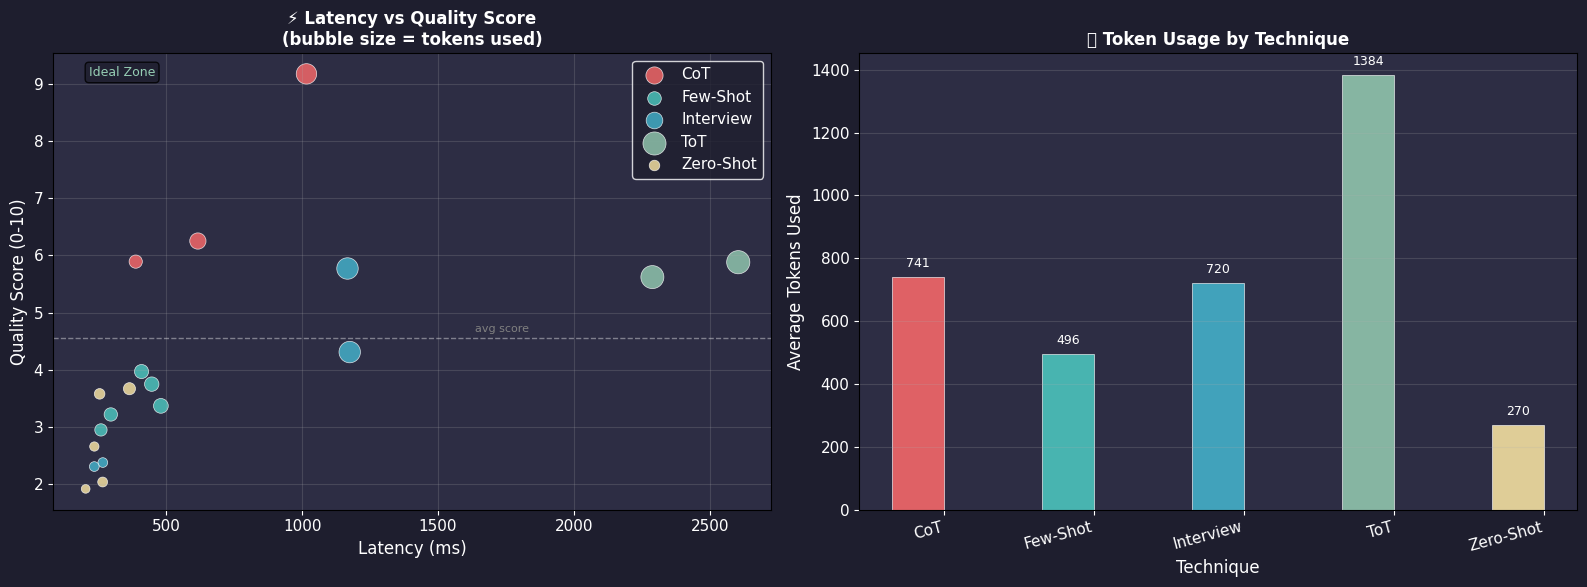

✅ Plot 2 saved


In [27]:
# ─────────────────────────────────────────────
# PLOT 2: Latency vs Score Scatter + Token size
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#1E1E2E')

# --- Scatter: Latency vs Score ---
ax = axes[0]
ax.set_facecolor('#2D2D44')

tech_groups = df.groupby('technique_group')
for i, (tech, group) in enumerate(tech_groups):
    color = color_list[i % len(color_list)]
    sizes = group['total_tokens'] / 5
    scatter = ax.scatter(
        group['latency_ms'], group['score'],
        s=sizes, alpha=0.8, c=color, label=tech,
        edgecolors='white', linewidths=0.5
    )

ax.set_xlabel('Latency (ms)', fontsize=12)
ax.set_ylabel('Quality Score (0-10)', fontsize=12)
ax.set_title('⚡ Latency vs Quality Score\n(bubble size = tokens used)', fontsize=12, fontweight='bold')
ax.legend(facecolor='#1E1E2E', edgecolor='white', labelcolor='white')
ax.grid(alpha=0.2)

# Add annotation
ax.annotate('Ideal Zone', xy=(0.05, 0.95), xycoords='axes fraction',
            color='#96CEB4', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1E1E2E', alpha=0.8))
ax.axhline(y=agg['score'].mean(), color='white', linestyle='--', alpha=0.4, linewidth=1)
ax.text(ax.get_xlim()[1]*0.6, agg['score'].mean()+0.1, 'avg score', color='gray', fontsize=8)

# --- Bar: Token Usage by Technique ---
ax2 = axes[1]
ax2.set_facecolor('#2D2D44')

techs = list(agg.index)
x = np.arange(len(techs))
width = 0.35

bars1 = ax2.bar(x - width/2, agg['total_tokens'], width, label='Total Tokens',
                color=color_list[:len(techs)], alpha=0.85, edgecolor='white', linewidth=0.5)

ax2.set_xlabel('Technique', fontsize=12)
ax2.set_ylabel('Average Tokens Used', fontsize=12)
ax2.set_title('🔢 Token Usage by Technique', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(techs, rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.2)

for bar in bars1:
    height = bar.get_height()
    ax2.annotate(f'{height:.0f}',
                 xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='bottom', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('/content/plot2_latency_tokens.png', dpi=150, bbox_inches='tight',
            facecolor='#1E1E2E')
plt.show()
print("✅ Plot 2 saved")

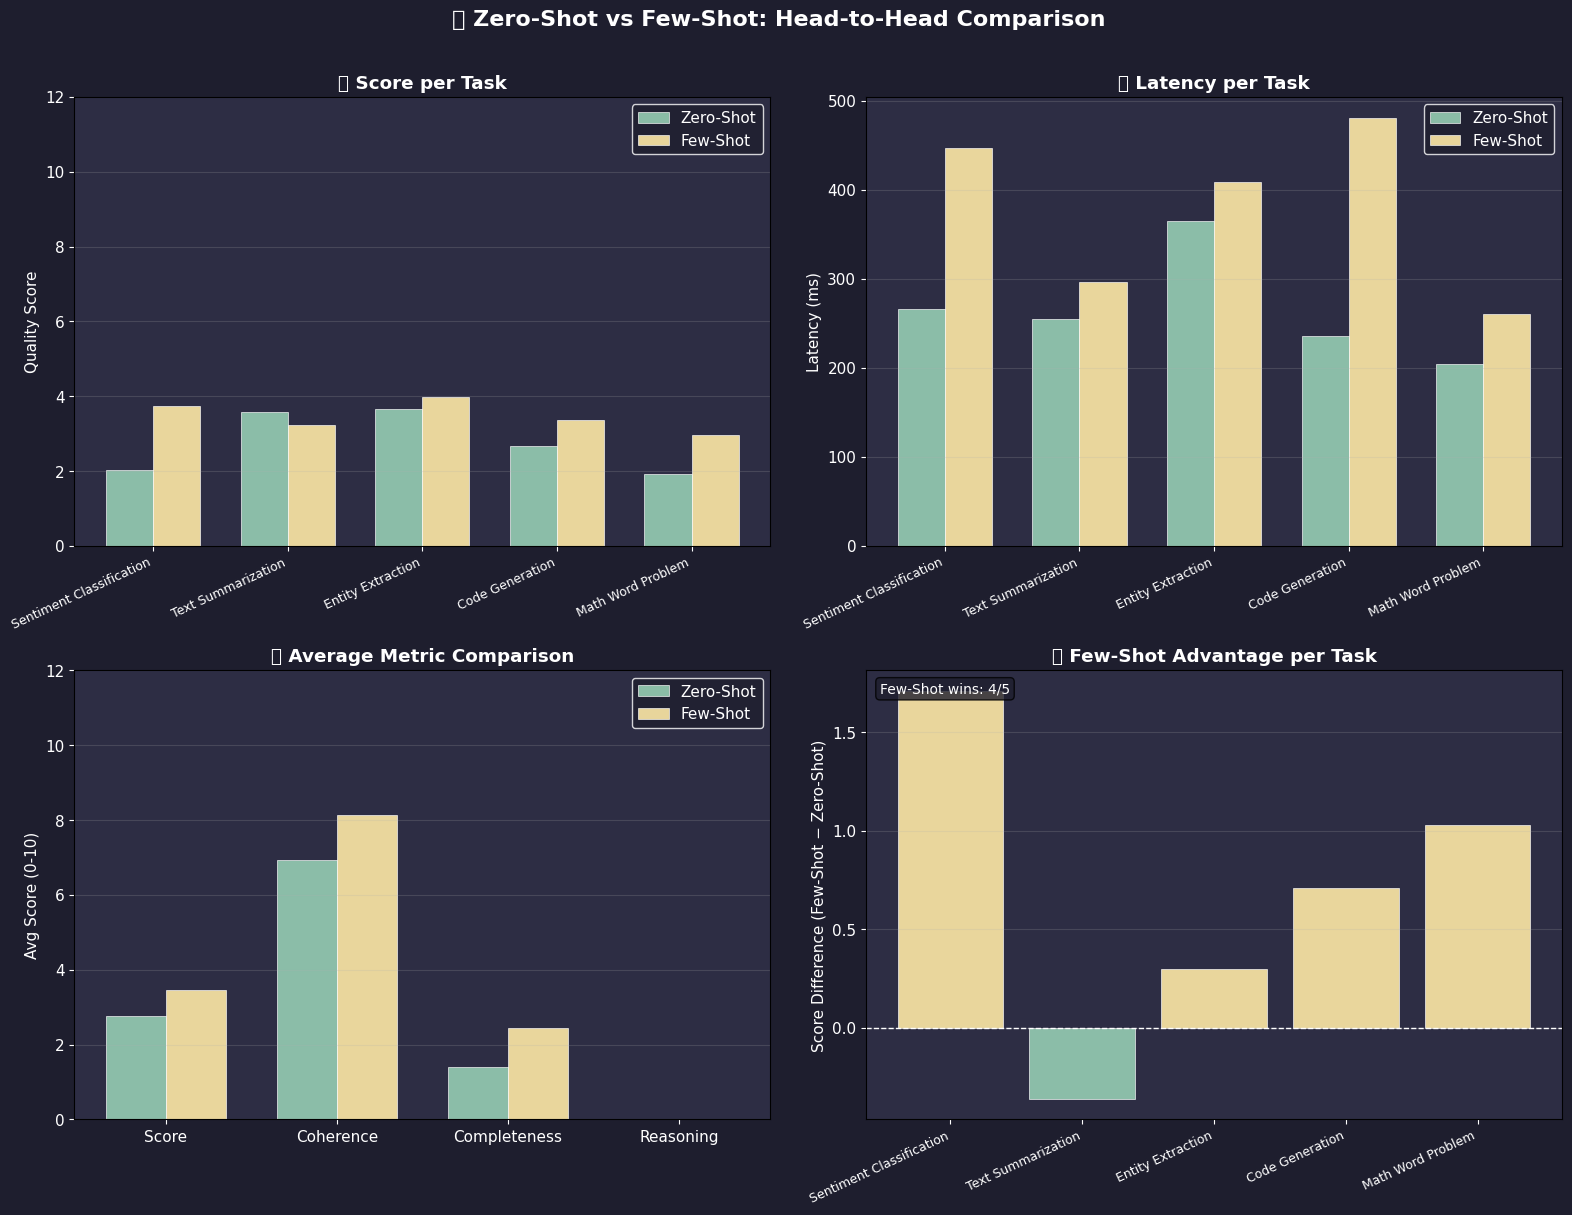

✅ Plot 3 saved


In [28]:
# ─────────────────────────────────────────────
# PLOT 3: Zero-Shot vs Few-Shot Comparison (head-to-head)
# ─────────────────────────────────────────────

# Build comparison DataFrame
zs_df = pd.DataFrame([
    {'task': r.task, 'score': r.score, 'latency': r.latency_ms,
     'tokens': r.total_tokens, 'technique': 'Zero-Shot',
     'coherence': r.coherence, 'completeness': r.completeness,
     'reasoning': r.reasoning_depth}
    for r in zero_shot_results
])

fs_df = pd.DataFrame([
    {'task': r.task, 'score': r.score, 'latency': r.latency_ms,
     'tokens': r.total_tokens, 'technique': 'Few-Shot',
     'coherence': r.coherence, 'completeness': r.completeness,
     'reasoning': r.reasoning_depth}
    for r in few_shot_results
])

compare_df = pd.concat([zs_df, fs_df], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='#1E1E2E')
fig.suptitle('🥊 Zero-Shot vs Few-Shot: Head-to-Head Comparison',
             fontsize=16, fontweight='bold', color='white', y=1.01)

task_labels = [t[:20] + '...' if len(t) > 20 else t for t in BENCHMARK_TASKS[:5]]
task_short  = [t['name'] for t in BENCHMARK_TASKS[:5]]

zs_scores = [r.score for r in zero_shot_results]
fs_scores  = [r.score for r in few_shot_results]

# ── Subplot 1: Score comparison per task ──
ax = axes[0, 0]
ax.set_facecolor('#2D2D44')
x = np.arange(len(task_short))
w = 0.35
bars_zs = ax.bar(x - w/2, zs_scores, w, label='Zero-Shot',
                 color=COLORS['zero_shot'], alpha=0.9, edgecolor='white', lw=0.5)
bars_fs = ax.bar(x + w/2, fs_scores, w, label='Few-Shot',
                 color=COLORS['few_shot'], alpha=0.9, edgecolor='white', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(task_short, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Quality Score')
ax.set_title('📊 Score per Task', fontweight='bold')
ax.legend(facecolor='#1E1E2E', edgecolor='white', labelcolor='white')
ax.grid(axis='y', alpha=0.2)
ax.set_ylim(0, 12)

# ── Subplot 2: Latency comparison ──
ax2 = axes[0, 1]
ax2.set_facecolor('#2D2D44')
zs_lat = [r.latency_ms for r in zero_shot_results]
fs_lat  = [r.latency_ms for r in few_shot_results]
ax2.bar(x - w/2, zs_lat, w, label='Zero-Shot',
        color=COLORS['zero_shot'], alpha=0.9, edgecolor='white', lw=0.5)
ax2.bar(x + w/2, fs_lat, w, label='Few-Shot',
        color=COLORS['few_shot'], alpha=0.9, edgecolor='white', lw=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(task_short, rotation=25, ha='right', fontsize=9)
ax2.set_ylabel('Latency (ms)')
ax2.set_title('⏱️ Latency per Task', fontweight='bold')
ax2.legend(facecolor='#1E1E2E', edgecolor='white', labelcolor='white')
ax2.grid(axis='y', alpha=0.2)

# ── Subplot 3: Metric breakdown (avg) ──
ax3 = axes[1, 0]
ax3.set_facecolor('#2D2D44')
metrics = ['score', 'coherence', 'completeness', 'reasoning']
metric_labels = ['Score', 'Coherence', 'Completeness', 'Reasoning']
zs_avg = [zs_df[m].mean() for m in metrics]
fs_avg  = [fs_df[m].mean() for m in metrics]

x3 = np.arange(len(metrics))
ax3.bar(x3 - w/2, zs_avg, w, label='Zero-Shot', color=COLORS['zero_shot'],
        alpha=0.9, edgecolor='white', lw=0.5)
ax3.bar(x3 + w/2, fs_avg, w, label='Few-Shot', color=COLORS['few_shot'],
        alpha=0.9, edgecolor='white', lw=0.5)
ax3.set_xticks(x3)
ax3.set_xticklabels(metric_labels)
ax3.set_ylabel('Avg Score (0-10)')
ax3.set_title('📈 Average Metric Comparison', fontweight='bold')
ax3.legend(facecolor='#1E1E2E', edgecolor='white', labelcolor='white')
ax3.grid(axis='y', alpha=0.2)
ax3.set_ylim(0, 12)

# ── Subplot 4: Win/Lose analysis ──
ax4 = axes[1, 1]
ax4.set_facecolor('#2D2D44')
diff = [f - z for f, z in zip(fs_scores, zs_scores)]
colors_diff = [COLORS['few_shot'] if d >= 0 else COLORS['zero_shot'] for d in diff]
bars = ax4.bar(task_short, diff, color=colors_diff, alpha=0.9, edgecolor='white', lw=0.5)
ax4.axhline(0, color='white', linewidth=1, linestyle='--')
ax4.set_ylabel('Score Difference (Few-Shot − Zero-Shot)')
ax4.set_title('🏆 Few-Shot Advantage per Task', fontweight='bold')
ax4.set_xticklabels(task_short, rotation=25, ha='right', fontsize=9)
ax4.grid(axis='y', alpha=0.2)

fs_wins = sum(1 for d in diff if d > 0)
ax4.text(0.02, 0.95, f'Few-Shot wins: {fs_wins}/{len(diff)}',
         transform=ax4.transAxes, color='white', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#1E1E2E', alpha=0.8))

plt.tight_layout()
plt.savefig('/content/plot3_zeroshot_fewshot.png', dpi=150, bbox_inches='tight',
            facecolor='#1E1E2E')
plt.show()
print("✅ Plot 3 saved")

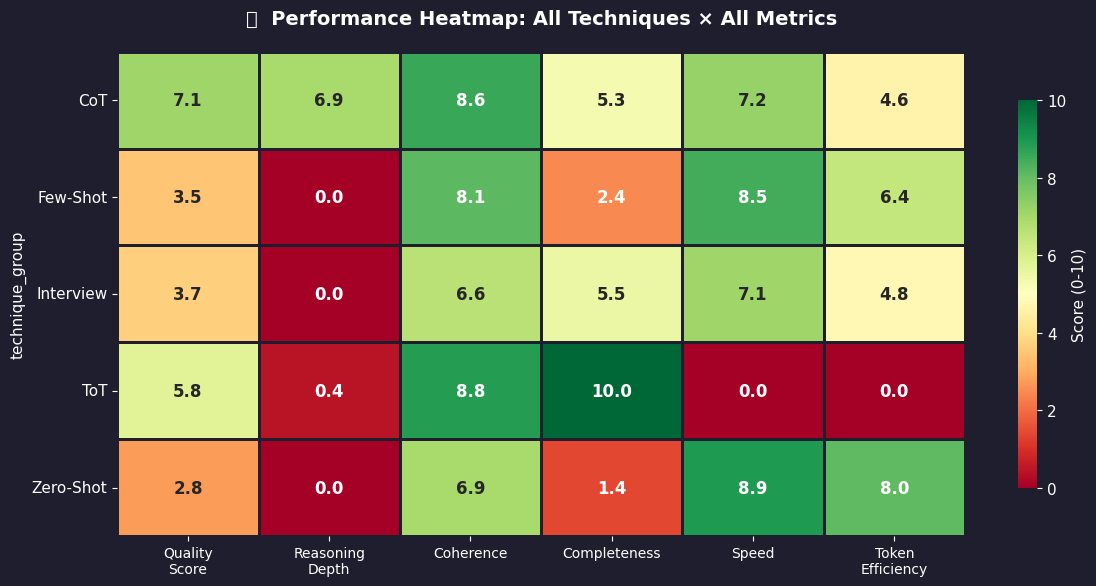

✅ Plot 4 saved


In [29]:
# ─────────────────────────────────────────────
# PLOT 4: All Techniques Comprehensive Heatmap
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 6), facecolor='#1E1E2E')
ax.set_facecolor('#2D2D44')

# Build heatmap matrix
metrics_cols = ['score', 'reasoning_depth', 'coherence', 'completeness', 'speed_score', 'token_efficiency']
metrics_labels = ['Quality\nScore', 'Reasoning\nDepth', 'Coherence', 'Completeness', 'Speed', 'Token\nEfficiency']

heatmap_data = agg[['score', 'reasoning_depth', 'coherence', 'completeness', 'speed_score', 'token_efficiency']]
heatmap_data.columns = metrics_labels

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=10,
    annot=True,
    fmt='.1f',
    linewidths=1,
    linecolor='#1E1E2E',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'label': 'Score (0-10)', 'shrink': 0.8}
)

ax.set_title('🌡️  Performance Heatmap: All Techniques × All Metrics',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('/content/plot4_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#1E1E2E')
plt.show()
print("✅ Plot 4 saved")

In [30]:
# ─────────────────────────────────────────────
# PLOT 5: Interactive Plotly Dashboard
# ─────────────────────────────────────────────

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        '📊 Overall Score by Technique',
        '⏱️ Latency Distribution',
        '🔢 Token Efficiency',
        '📈 Score Timeline (API calls)'
    ],
    specs=[[{'type': 'bar'}, {'type': 'box'}],
           [{'type': 'scatter'}, {'type': 'scatter'}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)

plotly_colors = [COLORS['interview'], COLORS['cot'], COLORS['tot'],
                 COLORS['zero_shot'], COLORS['few_shot']]

# ── Subplot 1: Bar chart of scores ──
for i, (tech, row) in enumerate(agg.iterrows()):
    fig.add_trace(
        go.Bar(name=tech, x=[tech], y=[row['score']],
               marker_color=plotly_colors[i % len(plotly_colors)],
               text=[f"{row['score']:.2f}"], textposition='outside',
               showlegend=False),
        row=1, col=1
    )

# ── Subplot 2: Box plot of latency ──
for i, (tech, group) in enumerate(df.groupby('technique_group')):
    fig.add_trace(
        go.Box(y=group['latency_ms'], name=tech,
               marker_color=plotly_colors[i % len(plotly_colors)],
               showlegend=False),
        row=1, col=2
    )

# ── Subplot 3: Bubble (tokens vs score) ──
for i, (tech, group) in enumerate(df.groupby('technique_group')):
    fig.add_trace(
        go.Scatter(
            x=group['total_tokens'], y=group['score'],
            mode='markers', name=tech,
            marker=dict(size=group['latency_ms']/100, color=plotly_colors[i % len(plotly_colors)],
                        opacity=0.8, line=dict(width=1, color='white')),
            text=group['task'], hovertemplate='<b>%{text}</b><br>Tokens: %{x}<br>Score: %{y:.2f}<extra></extra>',
            showlegend=True
        ),
        row=2, col=1
    )

# ── Subplot 4: Score over time ──
df_sorted = df.sort_values('timestamp').reset_index(drop=True)
for i, (tech, group) in enumerate(df_sorted.groupby('technique_group')):
    fig.add_trace(
        go.Scatter(
            x=group.index, y=group['score'],
            mode='lines+markers', name=f"{tech} (timeline)",
            line=dict(color=plotly_colors[i % len(plotly_colors)], width=2),
            marker=dict(size=8),
            showlegend=False
        ),
        row=2, col=2
    )

fig.update_layout(
    title_text='🧠 Prompt Engineering Dashboard — All Techniques',
    title_font=dict(size=18, color='white'),
    paper_bgcolor='#1E1E2E',
    plot_bgcolor='#2D2D44',
    font=dict(color='white', size=11),
    height=750,
    legend=dict(bgcolor='#1E1E2E', bordercolor='white', borderwidth=1)
)
fig.update_xaxes(showgrid=True, gridcolor='rgba(255,255,255,0.1)')
fig.update_yaxes(showgrid=True, gridcolor='rgba(255,255,255,0.1)')

fig.write_html('/content/dashboard_interactive.html')
fig.show()
print("✅ Interactive dashboard saved as HTML!")

✅ Interactive dashboard saved as HTML!


## 🔍 Cell 10: Comparative Analysis & Summary Statistics

In [31]:
print("="*70)
print("🔍  COMPARATIVE ANALYSIS & SUMMARY")
print("="*70)

# ─── Summary Table ───
summary = agg.copy()
summary['avg_latency_ms']      = summary['latency_ms'].round(0)
summary['avg_total_tokens']    = summary['total_tokens'].round(0)
summary['composite_score']     = summary['score'].round(2)
summary['calls_in_experiment'] = df.groupby('technique_group').size()

print("\n📋 FINAL SUMMARY TABLE")
print("─" * 70)
display(summary[['composite_score', 'reasoning_depth', 'coherence',
                  'completeness', 'avg_latency_ms', 'avg_total_tokens', 'calls_in_experiment']])

# ─── Rankings ───
print("\n🏆 RANKINGS")
print("─" * 40)
ranked = agg.sort_values('score', ascending=False)
medals = ['🥇', '🥈', '🥉', '4️⃣', '5️⃣']
for i, (tech, row) in enumerate(ranked.iterrows()):
    print(f"{medals[i]} {tech:15s} | Score: {row['score']:.2f} | "
          f"Latency: {row['latency_ms']:.0f}ms | Tokens: {row['total_tokens']:.0f}")

print("\n📊 ZERO-SHOT vs FEW-SHOT (Benchmark Tasks)")
print("─" * 60)
for i, task in enumerate(BENCHMARK_TASKS[:5]):
    if i < len(zero_shot_results) and i < len(few_shot_results):
        zs_s = zero_shot_results[i].score
        fs_s = few_shot_results[i].score
        winner = '📚 Few-Shot' if fs_s > zs_s else '🎯 Zero-Shot' if zs_s > fs_s else 'TIE'
        print(f"Task: {task['name']:<25} | ZS: {zs_s:.2f} | FS: {fs_s:.2f} | Winner: {winner}")

🔍  COMPARATIVE ANALYSIS & SUMMARY

📋 FINAL SUMMARY TABLE
──────────────────────────────────────────────────────────────────────


,composite_score,reasoning_depth,coherence,completeness,avg_latency_ms,avg_total_tokens,calls_in_experiment
technique_group,,,,,,,
CoT,7.10,6.93,8.58,5.29,674.0,741.0,3
Few-Shot,3.45,0.00,8.12,2.44,379.0,496.0,5
Interview,3.69,0.00,6.62,5.50,711.0,720.0,4
ToT,5.75,0.40,8.83,10.00,2446.0,1384.0,2
Zero-Shot,2.77,0.00,6.93,1.39,265.0,270.0,5



🏆 RANKINGS
────────────────────────────────────────
🥇 CoT             | Score: 7.10 | Latency: 674ms | Tokens: 741
🥈 ToT             | Score: 5.75 | Latency: 2446ms | Tokens: 1384
🥉 Interview       | Score: 3.69 | Latency: 711ms | Tokens: 720
4️⃣ Few-Shot        | Score: 3.45 | Latency: 379ms | Tokens: 496
5️⃣ Zero-Shot       | Score: 2.77 | Latency: 265ms | Tokens: 270

📊 ZERO-SHOT vs FEW-SHOT (Benchmark Tasks)
────────────────────────────────────────────────────────────
Task: Sentiment Classification  | ZS: 2.04 | FS: 3.75 | Winner: 📚 Few-Shot
Task: Text Summarization        | ZS: 3.58 | FS: 3.22 | Winner: 🎯 Zero-Shot
Task: Entity Extraction         | ZS: 3.67 | FS: 3.97 | Winner: 📚 Few-Shot
Task: Code Generation           | ZS: 2.66 | FS: 3.37 | Winner: 📚 Few-Shot
Task: Math Word Problem         | ZS: 1.92 | FS: 2.95 | Winner: 📚 Few-Shot


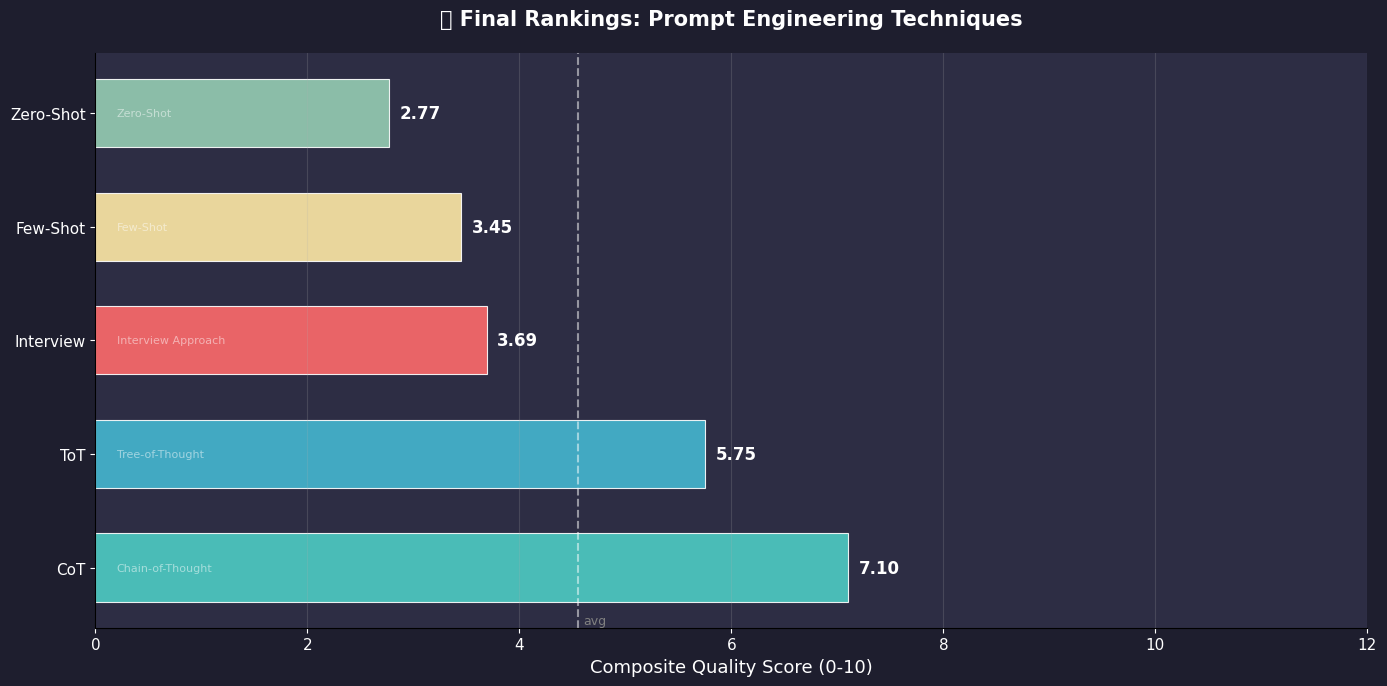

✅ Plot 5 saved


In [33]:
# ─────────────────────────────────────────────
# PLOT 6: Final Summary Bar Chart
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#1E1E2E')
ax.set_facecolor('#2D2D44')

techs_sorted = list(ranked.index)
scores_sorted = list(ranked['score'])
colors_sorted = [COLORS.get(t.lower().replace('-', '_').replace(' ', '_'), '#888')
                 for t in techs_sorted]

# Manual color mapping
color_map = {
    'Interview':  COLORS['interview'],
    'CoT':        COLORS['cot'],
    'ToT':        COLORS['tot'],
    'Zero-Shot':  COLORS['zero_shot'],
    'Few-Shot':   COLORS['few_shot'],
}
bar_colors = [color_map.get(t, '#888') for t in techs_sorted]

bars = ax.barh(techs_sorted, scores_sorted, color=bar_colors, alpha=0.9,
               edgecolor='white', linewidth=0.8, height=0.6)

for bar, score in zip(bars, scores_sorted):
    ax.text(score + 0.1, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', ha='left', color='white', fontweight='bold', fontsize=12)

ax.set_xlabel('Composite Quality Score (0-10)', fontsize=13)
ax.set_title('🏆 Final Rankings: Prompt Engineering Techniques',
             fontsize=15, fontweight='bold', pad=20)
ax.axvline(x=agg['score'].mean(), color='white', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(agg['score'].mean() + 0.05, -0.5, 'avg', color='gray', fontsize=9)
ax.set_xlim(0, 12)
ax.grid(axis='x', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add technique labels
for i, tech in enumerate(techs_sorted):
    ax.text(0.2, i, ['Interview Approach', 'Chain-of-Thought', 'Tree-of-Thought',
                     'Zero-Shot', 'Few-Shot'][['Interview','CoT','ToT','Zero-Shot','Few-Shot'].index(tech)]
            if tech in ['Interview','CoT','ToT','Zero-Shot','Few-Shot'] else tech,
            va='center', color='white', alpha=0.5, fontsize=8)

plt.tight_layout()
plt.savefig('/content/plot5_final_ranking.png', dpi=150, bbox_inches='tight',
            facecolor='#1E1E2E')
plt.show()
print("✅ Plot 5 saved")

## 📝 Cell 11: Theoretical Analysis — Compare & Contrast

In [34]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         PROMPT ENGINEERING: THEORETICAL COMPARE & CONTRAST          ║
╚══════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎤  INTERVIEW APPROACH
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mechanism:    Multi-turn conversation; LLM asks clarifying questions
              before generating final response.
Strengths:    • Reduces ambiguity in under-specified tasks
              • Produces highly personalized, contextual responses
              • Mirrors real expert consultation workflows
Weaknesses:   • Requires multiple API calls (higher cost & latency)
              • Not suitable for batch/automated pipelines
Best for:     Strategy planning, requirements gathering, tutoring,
              personalized recommendations.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔗  CHAIN-OF-THOUGHT (CoT)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mechanism:    Model explicitly verbalizes reasoning steps before
              arriving at the final answer.
Strengths:    • Dramatically improves accuracy on reasoning tasks
              • Makes model reasoning transparent and auditable
              • Self-correcting: errors caught mid-chain
Weaknesses:   • Higher token usage per query
              • Can be verbose for simple tasks
              • Quality depends on step-by-step prompt quality
Best for:     Math problems, logical reasoning, code debugging,
              multi-step analysis, scientific reasoning.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🌳  TREE-OF-THOUGHT (ToT)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mechanism:    Explores multiple reasoning branches in parallel,
              evaluates each, selects best path.
Strengths:    • Superior for problems requiring exploration of options
              • Finds optimal solutions by comparing alternatives
              • Mimics human expert deliberation
Weaknesses:   • Very high token consumption
              • Slowest technique; needs powerful models
              • Overkill for simple or well-defined tasks
Best for:     Strategic decisions, algorithm design, creative writing,
              policy analysis, complex research questions.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯  ZERO-SHOT PROMPTING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mechanism:    Direct instruction without any examples; relies on
              model's pre-trained world knowledge.
Strengths:    • Lowest token cost and lowest latency
              • Simple to implement; no example curation needed
              • Works well for well-defined, unambiguous tasks
Weaknesses:   • Inconsistent output format
              • Struggles with specialized or niche tasks
              • No format enforcement
Best for:     General Q&A, quick classifications, factual lookups,
              rapid prototyping and testing.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📚  FEW-SHOT PROMPTING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mechanism:    Provides 2-5 demonstration examples before the actual
              task, teaching format and style in-context.
Strengths:    • Consistent output formatting
              • Significantly better on specialized tasks
              • No fine-tuning required; adapts at inference time
Weaknesses:   • Higher input token cost (examples included)
              • Example quality critically affects performance
              • Limited by context window size
Best for:     Classification, extraction, code generation,
              translation, structured data tasks.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊  KEY INSIGHT: CHOOSING THE RIGHT TECHNIQUE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Task Type              Best Technique       Why
  ─────────────────────  ──────────────────   ──────────────────────────
  Ambiguous / open-ended Interview            Clarifies before answering
  Multi-step reasoning   CoT                  Shows intermediate steps
  Explore alternatives   ToT                  Evaluates multiple paths
  Batch classification   Few-Shot             Format consistency
  Quick factual query    Zero-Shot            Speed & cost efficiency
  Complex decisions      ToT + CoT hybrid     Best of both worlds

╔══════════════════════════════════════════════════════════════════════╗
║  CONCLUSION: No single technique dominates across all scenarios.     ║
║  Expert practitioners combine techniques for best results.           ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║         PROMPT ENGINEERING: THEORETICAL COMPARE & CONTRAST          ║
╚══════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎤  INTERVIEW APPROACH
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mechanism:    Multi-turn conversation; LLM asks clarifying questions
              before generating final response.
Strengths:    • Reduces ambiguity in under-specified tasks
              • Produces highly personalized, contextual responses
              • Mirrors real expert consultation workflows
Weaknesses:   • Requires multiple API calls (higher cost & latency)
              • Not suitable for batch/automated pipelines
Best for:     Strategy planning, requirements gathering, tutoring,
              personalized recommendations.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔗  C

In [36]:
# ─────────────────────────────────────────────
# FINAL: Export full results CSV
# ─────────────────────────────────────────────

df_final = pipeline.to_dataframe()
df_final.to_csv('/content/results.csv', index=False)

print("="*70)
print("🎉  EXPERIMENT COMPLETE!")
print("="*70)
print(f"\nTotal API calls made: {pipeline.call_count}")
print(f"Total tokens consumed: {df_final['total_tokens'].sum():,}")
print(f"Average latency: {df_final['latency_ms'].mean():.0f}ms")
print(f"\n📁 Output files:")
print("   • plot1_radar.png          — Radar chart")
print("   • plot2_latency_tokens.png — Latency & token analysis")
print("   • plot3_zeroshot_fewshot.png — ZS vs FS comparison")
print("   • plot4_heatmap.png        — Performance heatmap")
print("   • plot5_final_ranking.png  — Final ranking")
print("   • dashboard_interactive.html — Plotly dashboard")
print("   • results.csv              — Raw data")
print("\n" + "="*70)

🎉  EXPERIMENT COMPLETE!

Total API calls made: 19
Total tokens consumed: 11,704
Average latency: 683ms

📁 Output files:
   • plot1_radar.png          — Radar chart
   • plot2_latency_tokens.png — Latency & token analysis
   • plot3_zeroshot_fewshot.png — ZS vs FS comparison
   • plot4_heatmap.png        — Performance heatmap
   • plot5_final_ranking.png  — Final ranking
   • dashboard_interactive.html — Plotly dashboard
   • results.csv              — Raw data

